# 🌿 농작물 잎 병해충 진단 - MobileNetV3 학습

본 노트북은 `model.py`(PlantDiseaseCNN)와 `dataset.py`(Albumentations 데이터 파이프라인)를 결합하여 학습을 수행하고,  
에포크별 Loss/Accuracy 추이를 시각화한 뒤 최적 가중치를 `.pth` 파일로 저장합니다.

## 1. 환경 설정 및 모듈 임포트

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 프로젝트 내 커스텀 모듈 임포트
from model import PlantDiseaseMobileNetV3
from dataset import get_dataloaders

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\dltjr\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.12.0+cu126
CUDA Available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3080


## 2. 데이터로더 생성

In [2]:
# 데이터셋 경로 설정
base_dir = r"c:\Users\dltjr\Desktop\project\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"

BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows 환경 안정성을 위해 0

train_loader, val_loader = get_dataloaders(base_dir, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Loaded dataset from c:\Users\dltjr\Desktop\project\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train: 140590 images found across 38 classes.
Loaded dataset from c:\Users\dltjr\Desktop\project\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid: 35144 images found across 38 classes.

Train batches: 4394
Val batches:   1099


## 3. 모델 · 옵티마이저 · 손실함수 초기화

In [3]:
# 모델 생성 및 GPU 할당
model = PlantDiseaseMobileNetV3(num_classes=38).to(device)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 하이퍼파라미터 요약 출력
NUM_EPOCHS = 10
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss Function: CrossEntropyLoss")
print(f"Epochs: {NUM_EPOCHS}")

Total Parameters:     26,099,494
Trainable Parameters: 26,099,494
Optimizer: Adam (lr=0.001)
Loss Function: CrossEntropyLoss
Epochs: 10


## 4. 학습 및 검증 루프 (10 Epochs)

에포크별 Train Loss, Val Loss, Val Accuracy를 리스트에 기록하며 학습을 진행합니다.  
검증 정확도가 역대 최고치를 갱신할 때마다 `best_model.pth`로 가중치를 자동 저장합니다.

In [4]:
# 에포크별 기록을 저장할 리스트
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

print(f"Training started on device: {device}\n")

for epoch in range(NUM_EPOCHS):
    # ── 훈련(Train) 단계 ──
    model.train()
    running_loss = 0.0
    total_batches = len(train_loader)
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # 매 200배치마다 진행 상황 출력
        if (batch_idx + 1) % 200 == 0:
            print(f"  Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Batch [{batch_idx+1:04d}/{total_batches:04d}] Loss: {loss.item():.4f}")
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    
    # ── 검증(Validation) 단계 ──
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct / total
    
    # 기록 저장
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # 에포크 결과 출력
    print("=" * 70)
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  Train Loss: {epoch_train_loss:.4f}  |  Val Loss: {epoch_val_loss:.4f}  |  Val Acc: {epoch_val_acc:.4f}")
    
    # Best 모델 가중치 저장
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_model_mobilenet_v3.pth')
        print(f"  ★ Best model saved! (Val Acc: {best_val_acc:.4f})")
    
    print("=" * 70 + "\n")

# 마지막 에포크 가중치 저장
torch.save(model.state_dict(), 'last_model_mobilenet_v3.pth')
print(f"\nTraining complete!")
print(f"  - best_model_mobilenet_v3.pth saved (Best Val Acc: {best_val_acc:.4f})")
print(f"  - last_model_mobilenet_v3.pth saved (Final epoch weights)")

Training started on device: cuda

  Epoch [01/10] Batch [0200/4394] Loss: 3.5099
  Epoch [01/10] Batch [0400/4394] Loss: 3.3512
  Epoch [01/10] Batch [0600/4394] Loss: 3.3116
  Epoch [01/10] Batch [0800/4394] Loss: 3.5086
  Epoch [01/10] Batch [1000/4394] Loss: 3.1647
  Epoch [01/10] Batch [1200/4394] Loss: 3.2141
  Epoch [01/10] Batch [1400/4394] Loss: 3.2220
  Epoch [01/10] Batch [1600/4394] Loss: 3.1434
  Epoch [01/10] Batch [1800/4394] Loss: 3.6918
  Epoch [01/10] Batch [2000/4394] Loss: 3.1708
  Epoch [01/10] Batch [2200/4394] Loss: 3.1232
  Epoch [01/10] Batch [2400/4394] Loss: 3.2454
  Epoch [01/10] Batch [2600/4394] Loss: 3.3768
  Epoch [01/10] Batch [2800/4394] Loss: 2.9441
  Epoch [01/10] Batch [3000/4394] Loss: 3.0683
  Epoch [01/10] Batch [3200/4394] Loss: 2.7701
  Epoch [01/10] Batch [3400/4394] Loss: 2.4104
  Epoch [01/10] Batch [3600/4394] Loss: 2.7463
  Epoch [01/10] Batch [3800/4394] Loss: 2.8621
  Epoch [01/10] Batch [4000/4394] Loss: 2.8433
  Epoch [01/10] Batch [420

## 5. 학습 결과 시각화

에포크별 Train Loss / Val Loss 곡선과 Val Accuracy 곡선을 그래프로 출력합니다.

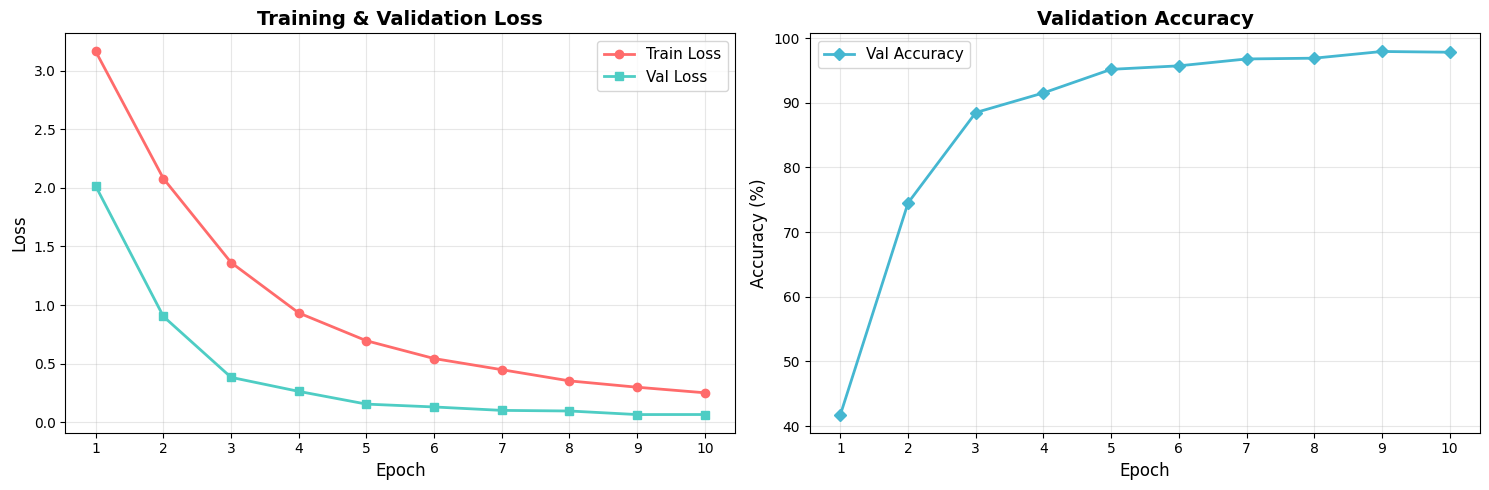


Graph saved as 'training_results.png'


In [5]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Loss 곡선 ──
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#FF6B6B', linewidth=2, markersize=6, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 's-', color='#4ECDC4', linewidth=2, markersize=6, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# ── Accuracy 곡선 ──
axes[1].plot(epochs_range, [acc * 100 for acc in history['val_acc']], 'D-', color='#45B7D1', linewidth=2, markersize=6, label='Val Accuracy')
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGraph saved as 'training_results.png'")

## 6. 최종 성능 요약

In [6]:
print("\n" + "=" * 50)
print("        FINAL TRAINING RESULTS SUMMARY")
print("=" * 50)
print(f"  Model:          PlantDiseaseCNN (4-Block CNN)")
print(f"  Parameters:     {trainable_params:,}")
print(f"  Epochs:         {NUM_EPOCHS}")
print(f"  Batch Size:     {BATCH_SIZE}")
print(f"  Optimizer:      Adam (lr=0.001)")
print(f"  Loss Function:  CrossEntropyLoss")
print("-" * 50)
print(f"  Final Train Loss:  {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss:    {history['val_loss'][-1]:.4f}")
print(f"  Final Val Acc:     {history['val_acc'][-1]*100:.2f}%")
print(f"  Best Val Acc:      {best_val_acc*100:.2f}%")
print("=" * 50)
print(f"\n  Saved: best_model.pth, last_model_mobilenet_v3.pth")
print(f"  Saved: training_results.png")


        FINAL TRAINING RESULTS SUMMARY
  Model:          PlantDiseaseCNN (4-Block CNN)
  Parameters:     26,099,494
  Epochs:         10
  Batch Size:     32
  Optimizer:      Adam (lr=0.001)
  Loss Function:  CrossEntropyLoss
--------------------------------------------------
  Final Train Loss:  0.2500
  Final Val Loss:    0.0643
  Final Val Acc:     97.81%
  Best Val Acc:      97.92%

  Saved: best_model.pth, last_model.pth
  Saved: training_results.png
